In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import itertools as it
import ast  # ast (Abstract Syntax Trees) is used for safely evaluating string literals
import os   # Used for creating and cleaning up the dummy file

from matplotlib.ticker import LogLocator, MaxNLocator, AutoLocator

In [60]:
### Import .csv file containing variance/expectation/time vs depth(column) vs graph(row) data
df = pd.read_csv(r'data_output_depth_60.csv')

In [62]:
df

,1,2,3,4,5,6,7,8,9,10,...,51,52,53,54,55,56,57,58,59,60
0,"{'variance': 0.0005874233459848467, 'expectati...","{'variance': 0.00108279701517378, 'expectation...","{'variance': 0.0022067098598871145, 'expectati...","{'variance': 0.0016587124506173508, 'expectati...","{'variance': 0.0013320305392003449, 'expectati...","{'variance': 0.0013987474268856723, 'expectati...","{'variance': 0.0014671079515854247, 'expectati...","{'variance': 0.0014825969885736356, 'expectati...","{'variance': 0.001413422712608922, 'expectatio...","{'variance': 0.0011493120878996788, 'expectati...",...,"{'variance': 0.0014098780968677094, 'expectati...","{'variance': 0.0016795543507189049, 'expectati...","{'variance': 0.0015015478678784007, 'expectati...","{'variance': 0.001397484996621129, 'expectatio...","{'variance': 0.001509767055653598, 'expectatio...","{'variance': 0.001661295405351769, 'expectatio...","{'variance': 0.001538571234279861, 'expectatio...","{'variance': 0.0015320948888714362, 'expectati...","{'variance': 0.001364573807895175, 'expectatio...","{'variance': 0.001449404473096545, 'expectatio..."
1,"{'variance': 0.0006819787519885715, 'expectati...","{'variance': 0.0017989515706724054, 'expectati...","{'variance': 0.0014975272688363779, 'expectati...","{'variance': 0.0015610232911454642, 'expectati...","{'variance': 0.001993239877142477, 'expectatio...","{'variance': 0.00210410357504966, 'expectation...","{'variance': 0.0017198039121668165, 'expectati...","{'variance': 0.0015395466559842525, 'expectati...","{'variance': 0.0015110151859882579, 'expectati...","{'variance': 0.0016532986725744747, 'expectati...",...,"{'variance': 0.002466260451737155, 'expectatio...","{'variance': 0.0020136605714349987, 'expectati...","{'variance': 0.00193967369580564, 'expectation...","{'variance': 0.002566261262266007, 'expectatio...","{'variance': 0.0020106872244313903, 'expectati...","{'variance': 0.0019731331908693956, 'expectati...","{'variance': 0.001989681988540746, 'expectatio...","{'variance': 0.002168585929979285, 'expectatio...","{'variance': 0.002098331407954944, 'expectatio...","{'variance': 0.002014240187776666, 'expectatio..."
2,"{'variance': 0.0005095670460634454, 'expectati...","{'variance': 0.0012199567698640084, 'expectati...","{'variance': 0.0015445774533347748, 'expectati...","{'variance': 0.0016956161858373974, 'expectati...","{'variance': 0.0017770940891556795, 'expectati...","{'variance': 0.0017302751742023289, 'expectati...","{'variance': 0.0012034703815221545, 'expectati...","{'variance': 0.0018771966800131365, 'expectati...","{'variance': 0.0017908637371524011, 'expectati...","{'variance': 0.0019172405637371812, 'expectati...",...,"{'variance': 0.0025327378932009704, 'expectati...","{'variance': 0.0024829681926415575, 'expectati...","{'variance': 0.0025812810974691625, 'expectati...","{'variance': 0.002551935513642278, 'expectatio...","{'variance': 0.0023968086335145735, 'expectati...","{'variance': 0.0020856110226259413, 'expectati...","{'variance': 0.002222568552883903, 'expectatio...","{'variance': 0.002406041570276583, 'expectatio...","{'variance': 0.002160058587642644, 'expectatio...","{'variance': 0.0022112507173148764, 'expectati..."
3,"{'variance': 0.00042807792021261657, 'expectat...","{'variance': 0.0013899459621832038, 'expectati...","{'variance': 0.0014331293320250455, 'expectati...","{'variance': 0.0011365244662950628, 'expectati...","{'variance': 0.0014629477746162887, 'expectati...","{'variance': 0.0015267852564687509, 'expectati...","{'variance': 0.001274146826477214, 'expectatio...","{'variance': 0.001434293976045314, 'expectatio...","{'variance': 0.0012974947685678378, 'expectati...","{'variance': 0.0012845353816106255, 'expectati...",...,"{'variance': 0.002318516344205751, 'expectatio...","{'variance': 0.0018527931785111867, 'expectati...","{'variance': 0.0022132080853231794, 'expectati...","{'variance': 0.002290233130772178, 'expectatio...","{'variance': 0.0025589091653627116, 'expectati...","{'variance': 0.0020

In [64]:
# Apply literal_eval to each column
for col in df.columns:
    df[col] = df[col].apply(ast.literal_eval)

In [66]:
### Plotting ###

# Helper function to save plots
def ensure_dir(directory):
    """Creates a directory if it doesn't exist."""
    if not os.path.exists(directory):
        os.makedirs(directory)
        print(f"Created directory: {directory}")

def save_plot(fig, outdir, filename, show=True):
    """Saves the plot to a file."""
    filepath = os.path.join(outdir, filename)
    fig.savefig(filepath, bbox_inches='tight', dpi=300)
    fig.savefig(filepath.replace('.png', '.pdf'), bbox_inches='tight')
    print(f"Plot saved to {filepath} (and .pdf)")
    if show:
        plt.show()
    else:
        plt.close(fig)

In [68]:
G1 = df.iloc[0]
print(G1.iloc[1])
# returns {'variance': 0.0018228715358671905, 'expectation': 0.534087626698114, 'time': 2.435081720352173}

{'variance': 0.00108279701517378, 'expectation': 0.5308778269024372, 'time': 2.7479658126831055}


In [340]:
G1 = df.iloc[0]
print(G1.iloc[1]['expectation'])
# returns 0.534087626698114

0.534087626698114


In [8]:
def plot_expectation_data(df, n_wires: int, n_param_samples: int =None,
                          outdir: str = "./figures", show: bool = True):
    """
    For fixed n vertices:
    Plot expectation value vs depth curves, per graph instance.
    Reads data directly from a prepared DataFrame.
    Saves as PNG and PDF.
    """
    print("\nStarting plotting function...")
    ensure_dir(outdir)
    fig, ax = plt.subplots(figsize=(3.5, 3.0))

    # Define marker styles (5 random graphs)
    marker_styles = it.cycle(['h','+','x','o','s',])

    # Get all unique graph IDs from the DataFrame
    G_1 = df.iloc[0]
    G_2 = df.iloc[1]
    G_3 = df.iloc[2]
    G_4 = df.iloc[3]
    G_5 = df.iloc[4]
    
    graphs = [G_1, G_2, G_3, G_4, G_5] # Sort them to keep order consistent
    graph_labels = it.cycle(['G1', 'G2', 'G3', 'G4', 'G5'])
    # Group the DataFrame by 'G_i' and plot each group
    for g in graphs:
        
        # Get the depths and expectations
        depths =[p+1 for p in range(df.shape[1])]
        expectations = [g.iloc[p-1]['expectation'] for p in depths]
        current_marker = next(marker_styles)
        current_label = next(graph_labels)
        ax.plot(depths, expectations, marker=current_marker, label=current_label)
    # --- All your formatting code remains the same ---
    ax.set_xlabel(r'Depth $p$')
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(AutoLocator())
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("Expectation of the loss function")
    # ax.set_yscale("log")
    # ax.set_title("Expectation vs Depth")
    ax.legend(fontsize=8)
    ax.grid(True, which='both')

    # Use the helper function to save the plot
    plot_filename = f"expectation_vs_depth_n_{n_wires}_{n_param_samples}_params.png"
    save_plot(fig, outdir, plot_filename, show=show)

In [72]:
def plot_variance_data(df, n_wires: int, n_param_samples: int =None,
                          outdir: str = "./figures", show: bool = True):
    """
    For fixed n vertices:
    Plot variance vs depth curves, per graph instance.
    Reads data directly from a prepared DataFrame.
    Saves as PNG and PDF.
    """
    print("\nStarting plotting function...")
    ensure_dir(outdir)
    fig, ax = plt.subplots(figsize=(3.5, 3.0))

    # Define marker styles (5 random graphs)
    marker_styles = it.cycle(['h','+','x','o','s',])

    # Get all unique graph IDs from the DataFrame
    G_1 = df.iloc[0]
    G_2 = df.iloc[1]
    G_3 = df.iloc[2]
    G_4 = df.iloc[3]
    G_5 = df.iloc[4]
    
    graphs = [G_1, G_2, G_3, G_4, G_5] # Sort them to keep order consistent
    graph_labels = it.cycle(['G1', 'G2', 'G3', 'G4', 'G5'])
    # Group the DataFrame by 'G_i' and plot each group
    for g in graphs:
        
        # Get the depths and expectations
        depths =[p+1 for p in range(df.shape[1])]
        expectations = [g.iloc[p-1]['variance'] for p in depths]
        current_marker = next(marker_styles)
        current_label = next(graph_labels)
        ax.plot(depths, expectations, marker=current_marker, label=current_label)
    # --- All formatting code goes the same ---
    ax.set_xlabel(r"Depth $p$")
    ax.set_xlim(left=0)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    
    ax.set_ylabel("Variance of the loss function")
    ax.set_yscale("log")
    ax.set_ylim([4e-4, 1e-2])
    custom_ticks = [1e-4, 5e-4,1e-3,5e-3]
    custom_labels = [
        r"$10^{-4}$",
        r"$5 \times 10^{-4}$",
        r"$10^{-3}$",
        r"$5 \times 10^{-3}$"]
    ax.set_yticks(custom_ticks, labels=custom_labels)
    #ax.set_title("Variance vs Depth")
    ax.legend(fontsize=8)
    ax.grid(True, which='both')

    # Use the helper function to save the plot
    plot_filename = f"variance_vs_depth_n_{n_wires}_{n_param_samples}_params.png"
    save_plot(fig, outdir, plot_filename, show=show)


Starting plotting function...
Plot saved to ./figures/expectation_vs_depth_n_10_50_params.png (and .pdf)


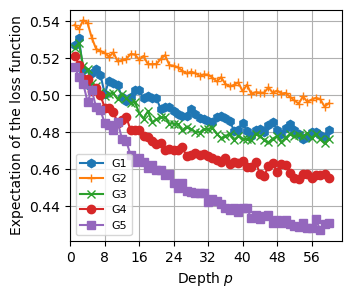


Starting plotting function...
Plot saved to ./figures/variance_vs_depth_n_10_50_params.png (and .pdf)


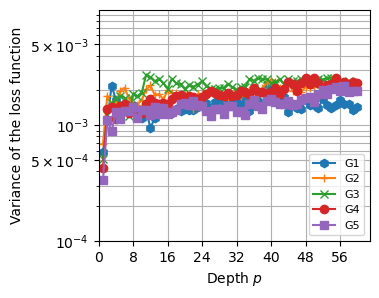

In [74]:
# Expectation and Variance plots

n_wires = 10
n_graphs = 5
max_depth = 60
n_param_samples=50
rng = np.random.default_rng(1234)

plot_expectation_data(df, n_wires, n_param_samples)
plot_variance_data(df, n_wires, n_param_samples)

In [77]:
### Import .csv file containing variance vs n_qubits(columns) vs graph(row) data
df2 = pd.read_csv(r'varrange_output_n_20.csv')

In [79]:
df2

,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.005198950312789107,0.0031833470859368262,0.0013758857159165583,0.0010793588430424365,0.0005016926112923058,0.0006131036220766891,0.0003690152197213688,0.00037174167585457915,0.0002745797761981708,0.00016419217727816013,9.604289730888606e-05,9.398447036163328e-05,8.310839799478857e-05,5.468861900856351e-05,5.2883340195713575e-05,4.197959761746635e-05,2.9808098746670688e-05
1,"[0.005198950312789107, 0.006080775950359577, 0...","[0.0031833470859368262, 0.003778613478848718, ...","[0.0016668910481437255, 0.0013758857159165583,...","[0.0012025382876199053, 0.0018688547224655408,...","[0.0008297420709627597, 0.0011275087441237487,...","[0.0006131036220766891, 0.0007920078348837576,...","[0.00044273242767536435, 0.00047106829129419, ...","[0.0005126219116227875, 0.00037174167585457915...","[0.00032399088925797565, 0.0002745797761981708...","[0.00018278264656386943, 0.0001882115328636358...","[0.00014875691437143078, 9.604289730888606e-05...","[0.00013523629437556397, 0.0001366163235270251...","[0.0001286560708135458, 0.00016934674683003845...","[0.00015020952097925995, 0.0001690498424684867...","[5.419033619600516e-05, 6.115549588020251e-05,...","[8.189190535756314e-05, 4.197959761746635e-05,...","[2.9808098746670688e-05, 3.593330556776304e-05..."
2,0.03579420398717595,0.02298659994762341,0.010081869514237085,0.0065340550558155965,0.005203479905912104,0.003565589575248695,0.002468671285530839,0.0021570839897344547,0.002026096890747758,0.0010547906552894224,0.0008234948261765196,0.0007034988319466896,0.0006888185171181925,0.000649522885056475,0.0005849873378139249,0.0003657730990313139,0.0003091958061649758
3,"[0.03468969712801681, 0.02035279064729806, 0.0...","[0.018275670964026457, 0.01604170571737479, 0....","[0.006592296656941294, 0.006614897593047539, 0...","[0.0065340550558155965, 0.006341450089816027, ...","[0.004026107861258241, 0.0037202330842307767, ...","[0.0019769217862597582, 0.0028296275691107892,...","[0.0013219271357417161, 0.002468671285530839, ...","[0.001552989747155743, 0.0015599481703042625, ...","[0.0012665714461940582, 0.0010016344938874474,...","[0.0010547906552894224, 0.0008647458102887426,...","[0.0007422770225579547, 0.0005871719906060723,...","[0.0005239174253889717, 0.0005304081756446387,...","[0.0006888185171181925, 0.00063097032381806, 0...","[0.0006208606928279056, 0.000649522885056475, ...","[0.0004247268595241686, 0.0004522513551637054,...","[0.0003657730990313139, 0.0002967748752696276,...","[0.00026113897472452555, 0.0002538549688570803..."


In [83]:
# print the variance data for n=4 up to n=10

print(df2['4'][0]) #absolute minimum
print(df2['4'][1]) #minimum variance over all depths for each 5 graphs
print(df2['4'][2]) #absolute maximum
print(df2['4'][3]) #maximum variance over all depths for each 5 graphs

0.005198950312789107
[0.005198950312789107, 0.006080775950359577, 0.005227316104881632, 0.0071589064722007816, 0.005367420456350684]
0.03579420398717595
[0.03468969712801681, 0.02035279064729806, 0.02672930445421521, 0.021400268489363907, 0.03579420398717595]


In [89]:
# Plots results from varrange_output.csv
def plot_variance_range(df, max_depth: int = None, n_param_samples: int = None,
                        outdir: str = "./figures", ref_scale: float = 1.0, show: bool = True):
    """
    For use with Plot min/max empirical variances across n, with an overlay reference curve ~ n^-4.
    Saves as PNG and PDF.
    """
    ensure_dir(outdir)
    
    mins = []
    maxs = []
    for n in range(df.shape[1]):
        column_index = df.columns[n]
        mins.append(float(df[column_index][0]))
        maxs.append(float(df[column_index][2]))

    ns_ax =[n+4 for n in range(df.shape[1])] #starting at n=4
    fig, ax = plt.subplots(figsize=(3.5, 3.0))
    ax.fill_between(ns_ax, mins, maxs, color="skyblue", alpha=0.4, label="Variance range")
    ax.plot(ns_ax, mins, "c--", label="Minimum")
    ax.plot(ns_ax, maxs, "c-", label="Maximum")

    # Overlay reference curve c * n^-4
    ref_curve = [ref_scale * (n ** -4) for n in ns_ax]
    ax.plot(ns_ax, ref_curve,'m-.', linewidth=2, label="Analytical lower bound")
    
    # --- All formatting code goes the same ---
    ax.set_xlabel(r"$n$ qubits")
    ax.set_ylabel("Variance of the loss function")
    ax.set_yscale("log")
    #ax.yaxis.set_major_locator(LogLocator(base=10.0))
    #ax.set_title(f"Variance range across graph instances")
    custom_ticks = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
    custom_labels = [
        r"$10^{-7}$",
        r"$10^{-6}$",
        r"$10^{-5}$",
        r"$10^{-4}$",
        r"$10^{-3}$",
        r"$10^{-2}$",
        r"$10^{-1}$",]
    ax.set_yticks(custom_ticks, labels=custom_labels)
    ax.grid(True, which="both")
    ax.legend(fontsize=8)

    save_plot(fig, outdir, f"variance_range_p_{max_depth}_{n_param_samples}_params.png", show=show)

Plot saved to ./figures/variance_range_p_15_50_params.png (and .pdf)


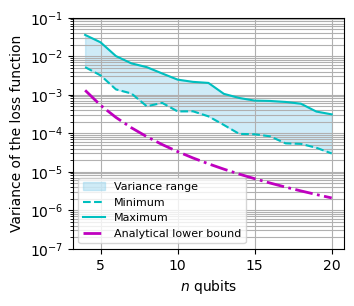

In [93]:
# Variance range plots

max_depth = 15
n_param_samples=50
rng = np.random.default_rng(1234)

plot_variance_range(df2, max_depth, n_param_samples, ref_scale = 1/3)

Ref's question asking about a paper that talks about the reachability deficit of GM-QAOA-->
We need p = 2^{n/2} to get convergence to an optimal solution. 
Get numerics that answer the depth p that gives an optimal solution.